## **Machine Learning**
### **Neural Network Generalization and Reliability**
#### * Project by: Archana Tirumala Narasimhan

* Install this Package for New Environment.
* pip install numpy pandas matplotlib seaborn scikit-learn tensorflow ipykernel notebook

In [211]:
import warnings
warnings.filterwarnings('ignore')

## Library Import

In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

## Data Import

In [213]:
df = pd.read_csv("Health_Risk_Tiers.csv")
df.head()

,Age,BMI,SBP,DBP,Resting_HR,HbA1c,LDL,HDL,Triglycerides,CRP,WBC,eGFR,Creatinine,Activity_Score,Sleep_Hours,LDL_Alt,CRP_Log,Random_Index,Risk_Tier
0,65,29.0,138,78,67,6.21,109,68,92,0.94,7.44,100,0.68,94,8.33,97,0.677,0.453,0
1,22,22.2,122,80,82,5.28,116,79,63,0.37,5.51,99,1.34,89,6.69,116,0.344,1.589,0
2,44,29.9,124,70,75,6.42,132,61,164,3.82,10.03,105,0.62,86,6.86,116,1.645,0.295,0
3,51,19.4,129,68,79,6.10,142,26,211,2.37,6.34,86,1.11,39,6.08,133,1.235,-2.478,2
4,55,32.6,117,73,73,4.90,110,59,40,1.90,7.45,97,0.88,46,6.94,107,1.149,1.951,0


## Data Overview
#### Dataset Shape

In [214]:
df.shape

(1500, 19)

#### Dataset Information

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1500 non-null   int64  
 1   BMI             1500 non-null   float64
 2   SBP             1500 non-null   int64  
 3   DBP             1500 non-null   int64  
 4   Resting_HR      1500 non-null   int64  
 5   HbA1c           1500 non-null   float64
 6   LDL             1500 non-null   int64  
 7   HDL             1500 non-null   int64  
 8   Triglycerides   1500 non-null   int64  
 9   CRP             1500 non-null   float64
 10  WBC             1500 non-null   float64
 11  eGFR            1500 non-null   int64  
 12  Creatinine      1500 non-null   float64
 13  Activity_Score  1500 non-null   int64  
 14  Sleep_Hours     1500 non-null   float64
 15  LDL_Alt         1500 non-null   int64  
 16  CRP_Log         1500 non-null   float64
 17  Random_Index    1500 non-null   f

#### Summary Statistics

In [216]:
df.describe()

,Age,BMI,SBP,DBP,Resting_HR,HbA1c,LDL,HDL,Triglycerides,CRP,WBC,eGFR,Creatinine,Activity_Score,Sleep_Hours,LDL_Alt,CRP_Log,Random_Index,Risk_Tier
count,1500.000000,1500.0000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,51.854000,26.8312,127.870667,79.732667,74.194000,5.656647,115.895333,52.534000,137.660000,1.935093,6.818080,91.317333,0.915673,59.779333,6.993720,116.290000,0.943208,0.004375,0.780000
std,13.861293,5.1450,17.298095,10.376431,10.535196,0.640550,26.732717,14.472012,63.202116,1.524458,1.191886,16.830572,0.275651,21.257812,0.820371,29.910461,0.536706,0.994048,0.965516
min,18.000000,16.0000,90.000000,50.000000,45.000000,4.500000,40.000000,20.000000,40.000000,0.100000,3.110000,36.000000,0.400000,0.000000,3.860000,40.000000,-0.144000,-3.237000,0.000000
25%,43.000000,23.2750,116.000000,73.000000,67.000000,5.190000,98.000000,42.750000,98.000000,0.717500,5.987500,80.000000,0.730000,45.000000,6.450000,96.000000,0.532500,-0.672500,0.000000
50%,52.000000,26.7000,128.000000,79.000000,74.000000,5.640000,117.000000,53.000000,132.000000,1.780000,6.835000,91.000000,0.920000,59.000000,7.000000,117.000000,1.015000,-0.017500,0.000000
75%,61.000000,30.3000,139.000000,86.000000,81.000000,6.100000,133.000000,63.000000,168.000000,2.820000,7.620000,102.250000,1.100000,75.000000,7.570000,137.000000,1.339000,0.663250,1.000000
max,90.000000,44.8000,194.000000,115.000000,105.000000,7.990000,210.000000,105.000000,500.000000,14.860000,11.120000,140.000000,1.880000,100.000000,9.650000,234.000000,2.709000,4.088000,3.000000


* Dataset contains 1,500 observations and 19 columns, including 18 numerical predictor variables and 1 target variable (Risk_Tier).
* All variables are numeric
* There are no missing values, which means the dataset is already well-structured for neural network modeling.
* The summary statistics indicate that the features are on different scales, which confirms the use of feature scaling before training the MLP.

## Part A - Pre-Analysis & Problem Framing

**1. Why accuracy may be misleading for this dataset?**
   
* The health risk dataset is imbalanced, with more patients in lower-risk tiers compared to higher-risk tiers. Hence, accuracy may be misleading.
* A model could achieve high accuracy simply by predicting the majority class more often, while performing poorly at identifying higher-risk patients.

* In healthcare risk prediction, misclassifying high-risk patients is serious because it could delay early intervention, monitoring, or treatment. 
* Therefore, accuracy alone does not fully reflect how well the model identifies patients who need attention.

* To address this limitation, we can use macro-averaged precision, recall, and F1-score , as they evaluate model performance equally across all risk tiers.

**2. Which evaluation metrics you will prioritize and why?**

* I prioritize macro-averaged precision, recall, and F1-score because they give equal importance to each risk tier, even if some tiers have fewer patients.

* Recall is especially important because it measures how well the model correctly identifies patients who truly belong to higher risk categories. Missing high-risk patients could lead to delayed monitoring or treatment.

* Precision helps ensure that patients predicted as high risk actually need attention, which helps avoid unnecessary concern or medical costs.

* F1-score balances both precision and recall, giving a more reliable measure of performance when the dataset is imbalanced.

* The confusion matrix also helps show where the model makes mistakes between different risk levels.

**3. Where you expect overfitting to occur and how you plan to control it?**

* Overfitting may occur because neural networks like feedforward MLP with dense layers can learn very detailed patterns from the training data, including noise that may not generalize well to new patients.
   
* Since this dataset includes many related health indicators such as blood pressure, cholesterol, glucose, and lifestyle factors, the model may start memorizing specific relationships instead of learning general patterns.

* This would show as training performance improving while validation performance stops improving.

* To reduce overfitting, I applied dropout regularization. Dropout randomly turns off some neurons during training, which helps the model learn more general patterns instead of depending too much on specific features.

* This improves the model’s ability to perform well on unseen patient data..

## Part B Data Preparation

## Exploratory Data Analysis (EDA)
#### Missing Value Check

In [217]:
df.isnull().sum()

Age               0
BMI               0
SBP               0
DBP               0
Resting_HR        0
HbA1c             0
LDL               0
HDL               0
Triglycerides     0
CRP               0
WBC               0
eGFR              0
Creatinine        0
Activity_Score    0
Sleep_Hours       0
LDL_Alt           0
CRP_Log           0
Random_Index      0
Risk_Tier         0
dtype: int64

* There are no missing values

#### Class Distribution

In [218]:
df["Risk_Tier"].value_counts()

Risk_Tier
0    780
1    390
2    210
3    120
Name: count, dtype: int64

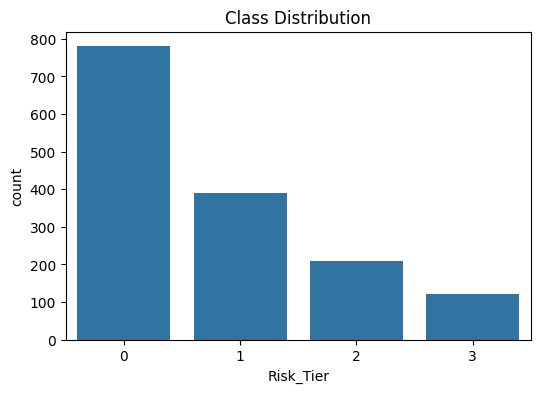

In [219]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk_Tier", data=df)
plt.title("Class Distribution")
plt.show()

* The target distribution shows clearly imbalanced, with Class 0 representing the majority of the observations and Class 3 representing the smallest group.
* This means that overall accuracy alone may be misleading. Hence, we should use macro-averaged precision, recall, and F1-score, which are more appropriate because they give equal importance to each class.

#### Feature Distribution 

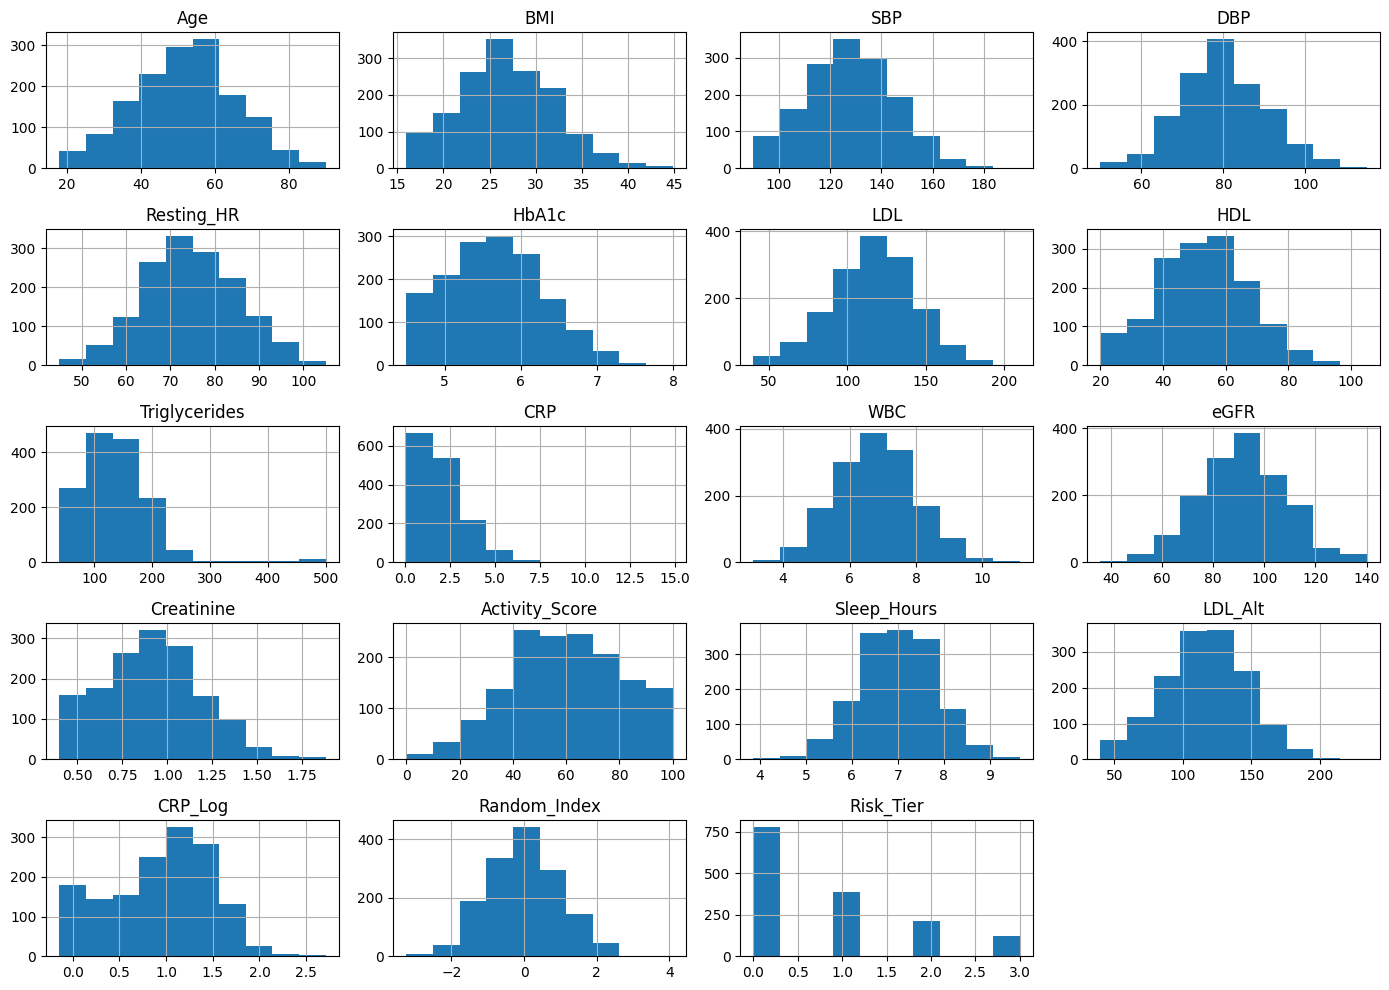

In [220]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

## Defining Feature and Target 

In [221]:
X = df.drop("Risk_Tier", axis=1)
y = df["Risk_Tier"]

### Data Preprocessing

#### Train-Validation-Test Split

In [222]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

* We split the dataset into training, validation, and test sets using a stratified approach so that the class distribution remains similar across all subsets.

## Feature Scaling

In [223]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaling_pipeline = Pipeline([("scaler", StandardScaler())])

X_train_scaled = scaling_pipeline.fit_transform(X_train)
X_val_scaled = scaling_pipeline.transform(X_val)
X_test_scaled = scaling_pipeline.transform(X_test)

 * Scaling is necessary because neural networks are sensitive to differences in feature magnitude or scales.
 * We applied feature scaling using StandardScaler inside a pipeline so that the scaling transformation is learned only from the training set and then consistently applied to the validation and test sets.
 * This prevents data leakage and improves reproducibility.


In [224]:
y_train_cat = to_categorical(y_train, 4)
y_val_cat = to_categorical(y_val, 4)
y_test_cat = to_categorical(y_test, 4)

## Pipeline for Model Comparison

* pip install scikeras

In [225]:
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier

# function for baseline ANN
def create_baseline_model():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(4, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# function for dropout ANN
def create_dropout_model():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dropout(0.30),
        Dense(16, activation='relu'),
        Dense(4, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KerasClassifier(model=create_baseline_model, epochs=100, batch_size=32, verbose=0))
])

dropout_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KerasClassifier(model=create_dropout_model, epochs=100, batch_size=32, verbose=0))
])

# train pipelines
baseline_pipeline.fit(X_train, y_train_cat)
dropout_pipeline.fit(X_train, y_train_cat)

# validation predictions
val_pred_base = baseline_pipeline.predict(X_val)
val_pred_drop = dropout_pipeline.predict(X_val)

## Part C – Baseline Neural Network

## Defining Baseline Model

In [226]:
def build_baseline_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

* The baseline architecture uses two hidden layers with 32 and 16 neurons.
* This provides enough capacity to capture nonlinear patterns in the tabular health data without making the network unnecessarily deep.
* I chose Relu for the hidden layers because it is efficient and widely used in neural networks, while softmax was used in the output layer with 4 neurons because the task is multiclass classification.

## Baseline Model Training

In [227]:
baseline_model = build_baseline_model(X_train.shape[1])

history_baseline = baseline_model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=32,
    verbose=0
)

## Learning Curve Function

In [228]:
def plot_curves(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

## Plotting Baseline Learning Curves

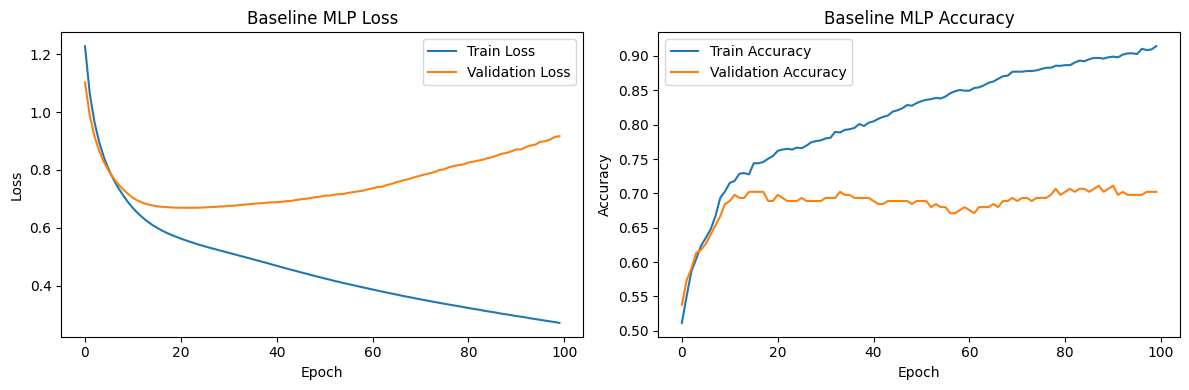

In [229]:
plot_curves(history_baseline, "Baseline MLP")

* The baseline MLP shows that the model is able to learn meaningful patterns from the data, but its validation performance is weaker than desired, especially when compared using the macro F1-score.
* This suggests that although the model fits the majority class reasonably well, it does not generalize equally well across all classes.

* The difference between training performance and validation performance indicates mild overfitting.
* The model performs better on training data than on unseen validation data, which suggests that it has started to learn patterns specific to the training dataset rather than general patterns that apply to new data.
* This is common when neural networks contain multiple dense layers, allowing them to capture complex relationships but also increasing the risk of memorization.

* However, the performance gap is not extremely large, so the model is not severely overfitting.
* It also does not show clear signs of underfitting, since the training performance is reasonably strong, indicating the model has sufficient capacity to learn patterns.
* Therefore, the baseline model represents a moderate fit with early signs of overfitting, suggesting that regularization techniques such as dropout may improve generalization performance.

## Part D – Controlled Regularization Experiment

## Regularization and Generalization Analysis

### Dropout-Regularized Model Definition

In [230]:
def build_dropout_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dropout(0.30),
        Dense(16, activation='relu'),
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Dropout Model Training

In [231]:
dropout_model = build_dropout_model(X_train.shape[1])

history_dropout = dropout_model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=32,
    verbose=0
)

## Plotting Dropout Learning Curves

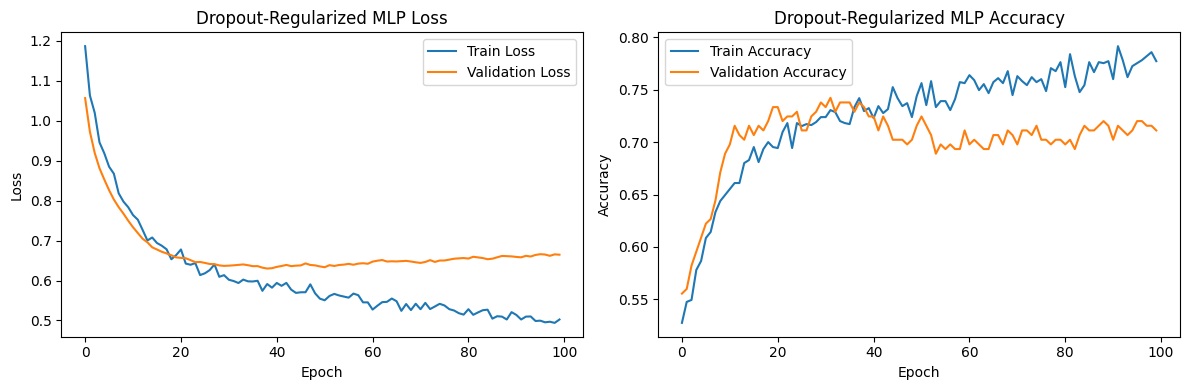

In [232]:
plot_curves(history_dropout, "Dropout-Regularized MLP")

## Dropout Validation Evaluation

In [233]:
val_pred_drop = np.argmax(dropout_model.predict(X_val_scaled, verbose=0), axis=1)
print(classification_report(y_val, val_pred_drop, digits=4))

              precision    recall  f1-score   support

           0     0.8655    0.8803    0.8729       117
           1     0.5962    0.5345    0.5636        58
           2     0.4571    0.5000    0.4776        32
           3     0.5263    0.5556    0.5405        18

    accuracy                         0.7111       225
   macro avg     0.6113    0.6176    0.6137       225
weighted avg     0.7109    0.7111    0.7104       225



* The dropout-regularized model achieved a validation accuracy of 0.7111 and a macro F1-score of 0.6137.
* Its strongest performance was on Class 0, which is expected because it is the majority class.
* Performance on Classes 1, 2, and 3 is lower, showing that minority classes remain more difficult to classify.
* However, the dropout model produced a better macro F1-score than the baseline model, indicating improved generalization across all classes rather than only strong performance on the dominant category.

## Comparing Validation Macro F1

In [234]:
# convert predicted probabilities to class labels
val_pred_base_labels = np.argmax(
    baseline_model.predict(X_val_scaled, verbose=0),
    axis=1
)

val_pred_drop_labels = np.argmax(
    dropout_model.predict(X_val_scaled, verbose=0),
    axis=1
)

# true labels already in numeric format
y_val_labels = y_val.values if hasattr(y_val, "values") else y_val

# compute macro F1
f1_base = f1_score(y_val_labels, val_pred_base_labels, average="macro")
f1_drop = f1_score(y_val_labels, val_pred_drop_labels, average="macro")

print("Baseline Macro F1:", f1_base)
print("Dropout Macro F1:", f1_drop)

Baseline Macro F1: 0.5963125885726505
Dropout Macro F1: 0.6136675501019038


* Dropout is a regularization technique that randomly disables a proportion of neurons during training.
* This prevents the network from relying too heavily on specific connections and encourages the model to learn more general patterns.
* The dropout-regularized MLP outperformed the baseline MLP on the validation set, increasing macro F1-score from 0.5963 to 0.6136 indicating generalization.
* This suggests that the baseline model was slightly overfitting, and dropout helped reduce this effect by improving performance across multiple classes rather than only the majority class.
* This improvement suggests that dropout helped the model generalize better across all classes, particularly in the presence of class imbalance.
* Because macro F1 gives equal weight to each class, this result is more meaningful than accuracy alone for selecting the best model.

## Best Model Selection

In [235]:
best_model = dropout_model if f1_drop > f1_base else baseline_model
best_model_name = "Dropout-Regularized MLP" if f1_drop > f1_base else "Baseline MLP"

print("Best model selected:", best_model_name)

Best model selected: Dropout-Regularized MLP


* Based on the higher validation macro F1-score, the Dropout-Regularized MLP should be selected as the final model.
* This choice is justified because our goal is to focus on generalization rather than training performance alone, and macro F1-score is the most appropriate selection metric for this imbalanced multiclass problem.

## Part E – Final Evaluation & Error Analysis

## Final Evaluation on Test Set

In [236]:
# Test Predictions
test_pred = np.argmax(best_model.predict(X_test_scaled, verbose=0), axis=1)

In [237]:
# Test Metrics
print("Best Model:", best_model_name)
print("Accuracy:", accuracy_score(y_test, test_pred))

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average='macro'
)

print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)

print(classification_report(y_test, test_pred, digits=4))

Best Model: Dropout-Regularized MLP
Accuracy: 0.7377777777777778
Macro Precision: 0.6955126379468486
Macro Recall: 0.7087270378003019
Macro F1: 0.7017347772103207
              precision    recall  f1-score   support

           0     0.8632    0.8632    0.8632       117
           1     0.5536    0.5254    0.5391        59
           2     0.5758    0.6129    0.5938        31
           3     0.7895    0.8333    0.8108        18

    accuracy                         0.7378       225
   macro avg     0.6955    0.7087    0.7017       225
weighted avg     0.7365    0.7378    0.7369       225



* On the test set, the model achieved an accuracy of 0.7378, along with a macro precision of 0.6955, macro recall of 0.7087, and macro F1-score of 0.7017.
* The model performs best on Class 0, with an F1-score of 0.8632, which is expected because it is the majority class.
* Performance on Classes 1 and 2 is lower, indicating that intermediate-risk categories are harder to distinguish.
* Class 3 performs relatively better than Class 2, suggesting that some high-risk cases are more separable than mid-level cases.
* Overall, the model shows reasonable generalization, but the lower minority-class scores indicate room for improvement.

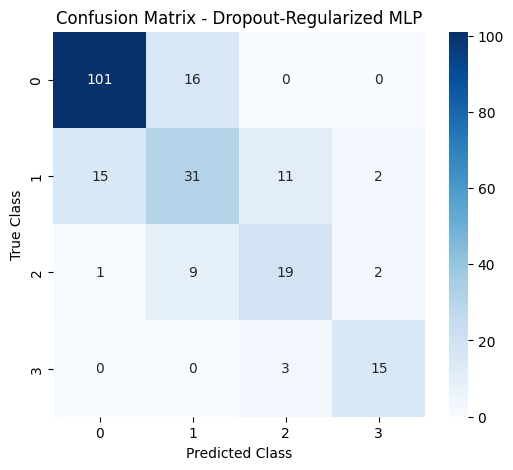

In [238]:
## Confusion Matrix
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Error Analysis

In [239]:
# Building Error Analysis Table
test_results = X_test.copy()
test_results["True_Label"] = y_test.values
test_results["Predicted_Label"] = test_pred
test_results["Correct"] = (test_results["True_Label"] == test_results["Predicted_Label"]).astype(int)

errors = test_results[test_results["Correct"] == 0]
errors.head()

,Age,BMI,SBP,DBP,Resting_HR,HbA1c,LDL,HDL,Triglycerides,CRP,...,eGFR,Creatinine,Activity_Score,Sleep_Hours,LDL_Alt,CRP_Log,Random_Index,True_Label,Predicted_Label,Correct
902,47,30.6,121,85,65,5.44,118,40,114,2.40,...,118,0.64,29,6.95,129,1.313,-0.495,2,1,0
1047,83,17.1,145,80,81,5.36,119,31,199,4.25,...,50,1.14,24,6.58,128,1.632,0.077,3,2,0
1240,58,24.7,162,80,75,6.37,150,59,167,1.03,...,69,1.28,50,7.61,147,0.534,0.091,2,3,0
586,67,31.1,120,76,77,4.81,118,39,124,2.55,...,112,0.72,69,6.45,107,1.144,0.031,0,1,0
742,58,18.9,122,92,73,5.09,158,41,153,0.10,...,77,1.00,55,6.72,178,0.101,0.094,0,1,0


In [240]:
# Errors by True Class
print(errors["True_Label"].value_counts().sort_index())

True_Label
0    16
1    28
2    12
3     3
Name: count, dtype: int64


In [241]:
# Most Common Confusion Pairs
error_pairs = errors.groupby(["True_Label", "Predicted_Label"]).size().sort_values(ascending=False)
print(error_pairs.head(10))

True_Label  Predicted_Label
0           1                  16
1           0                  15
            2                  11
2           1                   9
3           2                   3
1           3                   2
2           3                   2
            0                   1
dtype: int64


* Error analysis shows that the largest number of misclassifications occurs for Class 1, followed by Class 0.
* These results suggest that neighboring classes have similar feature characteristics, making them more difficult to separate compared to classes that are farther apart.
* This pattern is meaningful in a health-risk setting because risk tiers often represent gradual progression rather than sharply distinct categories. 
* A systematic error pattern is observed where the model struggles most with borderline cases between neighboring classes, indicating that decision boundaries between adjacent risk tiers are not clearly separated.
* Applying class weighting can directly address this issue by assigning greater importance to underrepresented and difficult classes during training, encouraging the model to learn more balanced boundaries and improve classification performance across similar risk groups.

## Part F – Model Reliability

In [242]:
# Predicted Confidence
probs = best_model.predict(X_test_scaled, verbose=0)
confidence = np.max(probs, axis=1)
correct = (test_pred == y_test.values).astype(int)

df_conf = pd.DataFrame({
    "confidence": confidence,
    "correct": correct
})

In [243]:
## Confidence Binning
df_conf["bin"] = pd.cut(df_conf["confidence"], bins=np.linspace(0, 1, 11), include_lowest=True)
reliability = df_conf.groupby("bin").agg(
    avg_confidence=("confidence", "mean"),
    accuracy=("correct", "mean"),
    count=("correct", "size")
).reset_index()

reliability

,bin,avg_confidence,accuracy,count
0,"(-0.001, 0.1]",NaN,NaN,0
1,"(0.1, 0.2]",NaN,NaN,0
2,"(0.2, 0.3]",NaN,NaN,0
3,"(0.3, 0.4]",NaN,NaN,0
4,"(0.4, 0.5]",0.465276,0.571429,14
5,"(0.5, 0.6]",0.551719,0.549020,51
6,"(0.6, 0.7]",0.646204,0.583333,36
7,"(0.7, 0.8]",0.753933,0.681818,22
8,"(0.8, 0.9]",0.857205,0.774194,31
9,"(0.9, 1.0]",0.968973,0.985915,71


## Reliability Plot

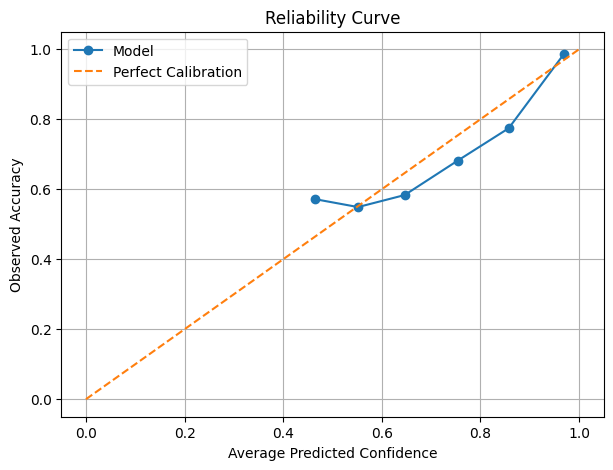

In [244]:
plt.figure(figsize=(7,5))
plt.plot(reliability["avg_confidence"], reliability["accuracy"], marker='o', label='Model')
plt.plot([0,1], [0,1], '--', label='Perfect Calibration')
plt.xlabel("Average Predicted Confidence")
plt.ylabel("Observed Accuracy")
plt.title("Reliability Curve")
plt.legend()
plt.grid(True)
plt.show()

* The reliability curve shows that predicted confidence closely matches actual accuracy, especially at higher confidence levels.
* The model slightly overestimates confidence in the mid-range (0.5–0.7), but predictions above 0.8 confidence are highly reliable.
* Overall, the model demonstrates good probability calibration.

## Confidence for Correct vs Incorrect Predictions

In [245]:
print("Average confidence for correct predictions:", df_conf[df_conf["correct"] == 1]["confidence"].mean())
print("Average confidence for incorrect predictions:", df_conf[df_conf["correct"] == 0]["confidence"].mean())

Average confidence for correct predictions: 0.7981388
Average confidence for incorrect predictions: 0.6335729


* The reliability analysis evaluates whether higher predicted probabilities correspond to higher actual accuracy. The results show a clear positive relationship between confidence and accuracy.

* Predictions with lower confidence levels between 0.4 and 0.6 show relatively low accuracy, around 45–47%, indicating that the model is less reliable when it is uncertain. As confidence increases, accuracy seems to improve steadily.

* For predictions with confidence between 0.8 and 0.9, the model achieves approximately 80.6% accuracy, showing strong reliability.

* The highest confidence group (0.9–1.0) achieves an accuracy of 96.1%, indicating that predictions with very high confidence are usually correct.

* The first few bins (0.0–0.4) contain no observations, which means the model rarely produces extremely low-confidence predictions. This suggests the model is generally robust in its classifications.

* Overall, the reliability results indicate that the predicted probabilities are reasonably well predicted, as accuracy increases consistently with confidence.

* One real-world risk of an overconfident model is that it may assign a very high probability to an incorrect prediction, causing decision-makers to trust the prediction too strongly. In a health-risk setting, this could result in a high-risk individual being incorrectly classified as low risk with high confidence, potentially delaying preventive care or early intervention.

## Conclusion

* In real-world healthcare, patient risk levels often fall on a spectrum rather than forming completely separate groups, meaning patients with similar symptoms or medical indicators may belong to adjacent risk categories. Our results showed that most misclassifications occurred between neighboring classes (Class 0 and Class 1), which reflects this real-world challenge.
* The improvement in validation macro F1-score after applying dropout indicates that the model generalizes better across all risk levels, helping reduce bias toward majority groups.
* Additionally, the higher average confidence for correct predictions (0.798) compared to incorrect ones (0.634) suggests that the model’s probability outputs can support healthcare professionals in identifying higher-risk patients while also recognizing cases that may require closer review, supporting better early intervention and resource prioritization.
* This project evaluated a feedforward neural network for multiclass health risk classification with emphasis on generalization, overfitting control, and reliability rather than accuracy alone.
* Exploratory analysis showed that the dataset was clean but imbalanced, which justified the use of macro-averaged evaluation metrics.
* The comparison between the baseline and dropout-regularized MLP showed that dropout improved the validation macro F1-score, indicating better generalization across all classes.
* Final test evaluation showed strong performance on the majority class and moderate performance on minority classes, while error analysis revealed that most mistakes occurred between adjacent risk tiers.
* Reliability analysis further showed that the model’s confidence is useful but not perfectly calibrated, meaning some high-confidence errors still occur.
* Overall, the results show that neural network evaluation should include not only predictive performance but also class-level fairness, error patterns, and confidence reliability.